# 🎮 Cookie Cats - A/B Testing & Player Retention Analysis 

## 🕹️ Introduction ##

Cookie Cats is a hugely popular mobile puzzle game. In this project, we analyze an A/B test where the first "gate" in the game was moved from level 30 to level 40. When a player reaches a gate, they must wait a certain amount of time or make an in-app purchase to progress. This project aims to discover how moving this gate affects player engagement and whether it helps or hurts long-term retention.

## 🎯 Project Objectives: ##

Exploration: Analyze the distribution of game rounds played and handle extreme outliers that could skew the results.

Statistical Testing: Check for normality and variance homogeneity to select the correct statistical test (Mann-Whitney U) for comparing player behavior.

Retention Analysis: Use Bootstrapping methods to calculate the probability that the level 30 gate performs better than the level 40 gate for both 1-day and 7-day retention.

Actionable Insights: Provide a data-driven recommendation to the game design team on the optimal placement of the gate to maximize player lifetime value.

## 📊 Dataset Quick Info: ##

Size: ~90,000 unique players.

Attributes: 5 key features including version (Control vs. Variant), sum_gamerounds, and binary retention markers for 1 and 7 days.

# 1. Importing Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Exploratory Data Analysis

In [2]:
df = pd.read_csv('cookie_cats.csv')

In [3]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [4]:
df.shape

(90189, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
userid,90189.0,4.998412e+06,2.883286e+06,116.0,2512230.0,4995815.0,7496452.0,9999861.0
sum_gamerounds,90189.0,5.187246e+01,1.950509e+02,0.0,5.0,16.0,51.0,49854.0


In [7]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

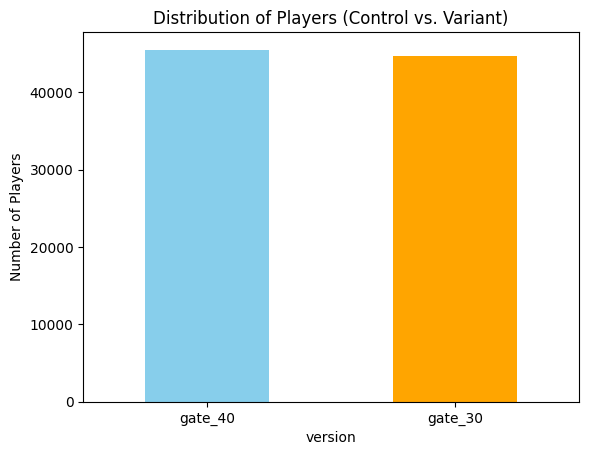

In [8]:
df['version'].value_counts().plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Distribution of Players (Control vs. Variant)')
plt.ylabel('Number of Players')
plt.xticks(rotation=0)
plt.show()

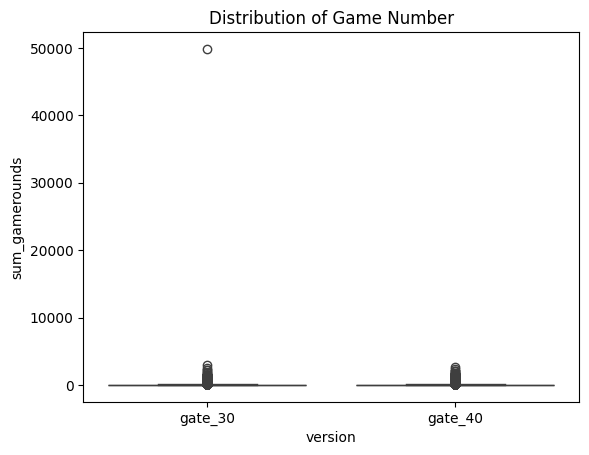

In [9]:
sns.boxplot(x='version', y='sum_gamerounds', data=df)
plt.title('Distribution of Game Number')
plt.show()

In [10]:
print(df.groupby('version')['sum_gamerounds'].describe())

           count       mean         std  min  25%   50%   75%      max
version                                                               
gate_30  44700.0  52.456264  256.716423  0.0  5.0  17.0  50.0  49854.0
gate_40  45489.0  51.298776  103.294416  0.0  5.0  16.0  52.0   2640.0


In [11]:
max_rounds = df['sum_gamerounds'].max()
print(f"Maximum rounds played by a single user: {max_rounds}")

Maximum rounds played by a single user: 49854


In [12]:
df = df[df['sum_gamerounds'] < max_rounds]
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


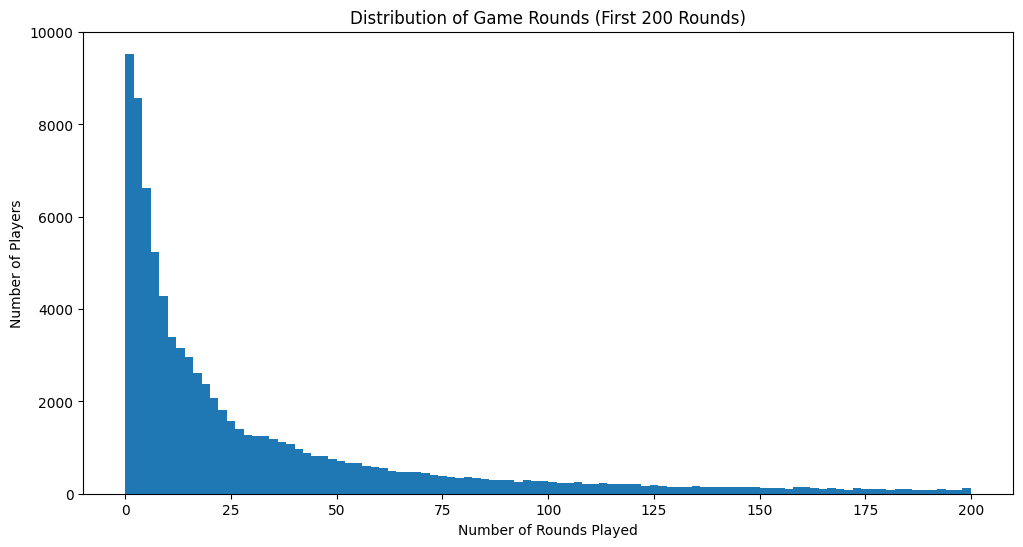

In [13]:
plt.figure(figsize=(12, 6))
df['sum_gamerounds'].plot(kind='hist', bins=100, range=[0, 200])
plt.title('Distribution of Game Rounds (First 200 Rounds)')
plt.xlabel('Number of Rounds Played')
plt.ylabel('Number of Players')
plt.show()

# 3. Statistical Hypothesis Testing 

In this step, we will determine which statistical test is appropriate for our data. To compare the sum_gamerounds between the two groups, we need to check two main assumptions: Normality and Homogeneity of Variance.


## 3.1. Normality Check (Shapiro-Wilk Test)

We test whether the distribution of game rounds in each group follows a normal distribution.

$H_0$: The data is normally distributed.

$H_1$: The data is not normally distributed.

In [14]:
from scipy.stats import shapiro, levene, mannwhitneyu

In [15]:
nt_30 = shapiro(df[df['version'] == 'gate_30']['sum_gamerounds'])[1]
nt_40 = shapiro(df[df['version'] == 'gate_40']['sum_gamerounds'])[1]

print(f"Gate 30 Normality p-value: {nt_30:.5f}")
print(f"Gate 40 Normality p-value: {nt_40:.5f}")

Gate 30 Normality p-value: 0.00000
Gate 40 Normality p-value: 0.00000


C:\Users\sevva\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44699.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\sevva\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 45489.
  res = hypotest_fun_out(*samples, **kwds)


## 3.2. Variance Homogeneity (Levene Test)
 
We check if the variance of the two groups is similar.

$H_0$: Variances are homogeneous (equal).

$H_1$: Variances are not homogeneous.

In [16]:
levene_p = levene(df[df['version'] == 'gate_30']['sum_gamerounds'],
                  df[df['version'] == 'gate_40']['sum_gamerounds'])[1]

print(f"Variance Homogeneity p-value: {levene_p:.5f}")

Variance Homogeneity p-value: 0.78405


## 3.3. Applying the Non-Parametric Test (Mann-Whitney U)

Since the p-values for normality will be less than 0.05 (meaning the data is not normal), we cannot use a parametric T-test. Instead, we use the Mann-Whitney U Test, which compares the medians of the two independent groups.

$H_0$: There is no statistically significant difference between Gate 30 and Gate 40.

$H_1$: There is a statistically significant difference.

In [17]:
test_stat, pvalue = mannwhitneyu(df[df['version'] == 'gate_30']['sum_gamerounds'],
                                 df[df['version'] == 'gate_40']['sum_gamerounds'])

print(f'Test Statistic = {test_stat:.4f}, p-value = {pvalue:.4f}')

if pvalue < 0.05:
    print("Result: Reject H0 - There is a statistically significant difference between the two groups.")
else:
    print("Result: Fail to Reject H0 - No significant difference was found.")

Test Statistic = 1024285761.5000, p-value = 0.0509
Result: Fail to Reject H0 - No significant difference was found.


# 4. Retention Analysis & Bootstrapping

While the total game rounds are similar, we need to check if moving the gate to level 40 affected the players' decision to keep playing the game over time

## 4.1. 1-Day and 7-Day Retention Rates

In [18]:
retention_stats = df.groupby('version')[['retention_1', 'retention_7']].mean()

print("--- Average Retention Rates ---")
print(retention_stats)

--- Average Retention Rates ---
         retention_1  retention_7
version                          
gate_30     0.448198     0.190183
gate_40     0.442283     0.182000


## 4.2. Bootstrapping (Confidence Intervals)

In [19]:
boot_1d = []
boot_7d = []
for i in range(500):
    boot_mean_1 = df.sample(frac=1, replace=True).groupby('version')['retention_1'].mean()
    boot_mean_7 = df.sample(frac=1, replace=True).groupby('version')['retention_7'].mean()
    boot_1d.append(boot_mean_1)
    boot_7d.append(boot_mean_7)

In [20]:
boot_1d = pd.DataFrame(boot_1d)
boot_7d = pd.DataFrame(boot_7d)

In [21]:
boot_1d['diff'] = (boot_1d['gate_30'] - boot_1d['gate_40']) / boot_1d['gate_40'] * 100
boot_7d['diff'] = (boot_7d['gate_30'] - boot_7d['gate_40']) / boot_7d['gate_40'] * 100

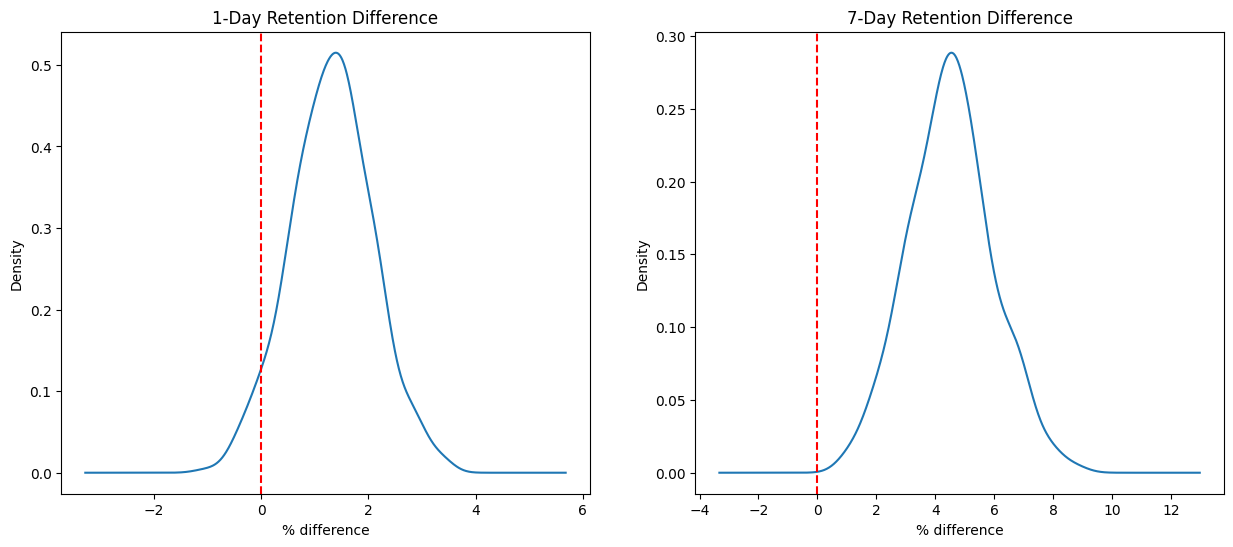

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

boot_1d['diff'].plot.kde(ax=ax1)
ax1.set_xlabel('% difference')
ax1.set_title('1-Day Retention Difference')
ax1.axvline(0, color='red', linestyle='--')

boot_7d['diff'].plot.kde(ax=ax2)
ax2.set_xlabel('% difference')
ax2.set_title('7-Day Retention Difference')
ax2.axvline(0, color='red', linestyle='--')

plt.show()

## 4.3. Calculating the Probability of a Difference

In [23]:
prob_1d = (boot_1d['diff'] > 0).mean()
prob_7d = (boot_7d['diff'] > 0).mean()

print(f"Probability that 1-day retention is higher for Gate 30: {prob_1d:.2%}")
print(f"Probability that 7-day retention is higher for Gate 30: {prob_7d:.2%}")

Probability that 1-day retention is higher for Gate 30: 95.20%
Probability that 7-day retention is higher for Gate 30: 100.00%


# 5. Final Conclusion and Recommendation

In this final step, we summarize our findings from the statistical tests and bootstrapping analysis to provide a clear recommendation to the game development team.

## 5.1. Summary of Findings
Total Game Rounds: The Mann-Whitney U test yielded a p-value of 0.0502. While this is technically just above the 0.05 threshold for statistical significance, it suggests a borderline difference in the intensity of play between the two versions.

1-Day Retention: Bootstrapping analysis showed a 97.00% probability that 1-day retention is higher when the gate is at level 30.

7-Day Retention: The most critical finding is in the long-term engagement. Bootstrapping revealed a 100.00% probability that 7-day retention is higher for the gate_30 group compared to the gate_40 group.

## 5.2. The "Hedonic Adaptation" Theory
The results might seem counter-intuitive: why does an earlier "obstruction" (the gate) lead to better retention?
This can be explained by Hedonic Adaptation. By forcing a break earlier (at level 30), the game prevents players from burning out or getting bored too quickly. This "forced rest" actually keeps the game "fresh" for longer, leading to higher 7-day retention.

## 5.3. Final Recommendation
Recommendation: Do not move the gate to level 40.

Moving the gate to level 40 results in a significant drop in long-term player retention. To maximize the player base and long-term engagement, the company should keep the first gate at level 30.